# AmBe Source-No Source Comparison

Strictly necessary codes for comparing 10% of clustered AmBe Source-No Source data.

DBSCAN parameters: eps = 1, minimum cluster size = 3

In [1]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import os, sys
import traceback
import glob
import pandas as pd

import h5flow 
plt.style.use('../../utils/dune.mplstyle')
from sklearn.cluster import DBSCAN

# Path to repo root (two directories above notebook)
light_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(light_root)

from light.PMT_analysis_utils import * 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

# TODO: Delete redundant packages

### Load data

In [2]:
# The ###us here refers to the delay trigger period
# Only sampling the prompt trigger for the comparison right now

df_109us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_109us_period_20260409_1510/AmBe_mod2_pmt_trigger_109us_period_clusters_prompt.csv', index_col=0)
df_128us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_128us_period_20260409_1524/AmBe_mod2_pmt_trigger_128us_period_clusters_prompt.csv', index_col=0)
df_147us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_147us_period_20260409_1535/AmBe_mod2_pmt_trigger_147us_period_clusters_prompt.csv', index_col=0)
df_176us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_176us_period_20260409_1539/AmBe_mod2_pmt_trigger_176us_period_clusters_prompt.csv', index_col=0)
df_195us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_195us_period_20260409_1557/AmBe_mod2_pmt_trigger_195us_period_clusters_prompt.csv', index_col=0)
df_224us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_224us_period_20260409_1557/AmBe_mod2_pmt_trigger_224us_period_clusters_prompt.csv', index_col=0)
df_272us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_272us_period_20260409_1603/AmBe_mod2_pmt_trigger_272us_period_clusters_prompt.csv', index_col=0)
df_291us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_291us_period_20260409_1645/AmBe_mod2_pmt_trigger_291us_period_clusters_prompt.csv', index_col=0)
df_320us = pd.concat([pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_320us_period_20260409_1645/AmBe_mod2_pmt_trigger_320us_period_clusters_prompt.csv', index_col=0),
                     pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_320us_period_set_B_20260409_1654/AmBe_mod2_pmt_trigger_320us_period_set_B_clusters_prompt.csv', index_col=0)], axis=0)
df_80us = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_80us_period_set_B_20260409_1718/AmBe_mod2_pmt_trigger_80us_period_set_B_clusters_prompt.csv', index_col=0)
df_32us_onetrig = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/AmBe_mod2_pmt_trigger_32us_period_20260409_1713/AmBe_mod2_pmt_trigger_32us_period_clusters_prompt.csv', index_col=0)
df_32us_onetrig_nosource = pd.read_csv('/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/no_source_32us_window_20260309_070118_clusters.csv', index_col=0)

In [3]:
# Combine datasets as needed

df_source_li = [df_109us, df_128us, df_147us, df_176us, df_195us, df_224us, df_272us, df_291us, df_320us, df_80us, df_32us_onetrig]

In [4]:
# Load MC
df_MC = pd.read_csv('../output/eps1_minsamples3/MC_AmBe_Prod_05-29_eps1size3.csv', index_col=0)

In [5]:
# Utility functions

def get_exposure_prompt(df):
    # Get total exposure time of a prompt trigger df in unit of seconds
    return len(np.unique(df['file_id']))*90


def charge_to_energy_mev(charge_ke):
    # Function for recalibrating energy
    return (np.asarray(charge_ke, dtype=np.float64) * 1e3 * 23.6) / 0.58 / 1e6

def get_clust_E(df, min_clust_size=4):
    # Get cluster energies in MeV from a dataframe
    cluster_E = []
    for i in np.unique(df['id']):
        hits_E = df['E'][(df['id']==i) & (df['cluster_label']!=-1)]
        # Additonal minimum cluster size cut
        if len(hits_E) >= min_clust_size:
            cluster_E.append(sum(df['E'][(df['id']==i) & (df['cluster_label']!=-1)].astype(float)))
        else:
            pass
    return np.array(cluster_E)

### Loop over dataframes to conduct analysis

In [6]:
periods = [109, 128, 147, 176, 195, 224, 272, 291, 320, 80, 32]  # in us
bins_range = np.arange(0,10,0.5)

# manually recorded exposure time corresponding to each period (10% of total file durations)
exposure_times = [1626, 3234, 1518, 2940, 1452, 2916, 2886, 1470, 3222, 9162, 8214]

In [ ]:
# Get MC cluster energy & exposure time
MC_clust_E = get_clust_E(df_MC, min_clust_size=4)
#MC_clust_exposure = get_exposure_prompt(df_MC)
MC_clust_E_hist, _ = np.histogram(MC_clust_E, bins=bins_range)
#MC_clust_E_hist = MC_clust_E_hist/MC_clust_exposure
MC_clust_E_hist_err = np.sqrt(MC_clust_E_hist)

# No Source
nosource_clust_E = get_clust_E(df_32us_onetrig_nosource, min_clust_size=4)
nosource_clust_exposure = 196 # Manually entered expoure time according to runlog
nosource_clust_E_hist, _ = np.histogram(nosource_clust_E, bins=bins_range)
nosource_clust_E_hist = nosource_clust_E_hist/nosource_clust_exposure # Normalized by exposure time
nosource_clust_E_hist_err = np.sqrt(nosource_clust_E_hist*nosource_clust_exposure)/nosource_clust_exposure
#nosource_clust_E_hist_err = np.sqrt(nosource_clust_E_hist)

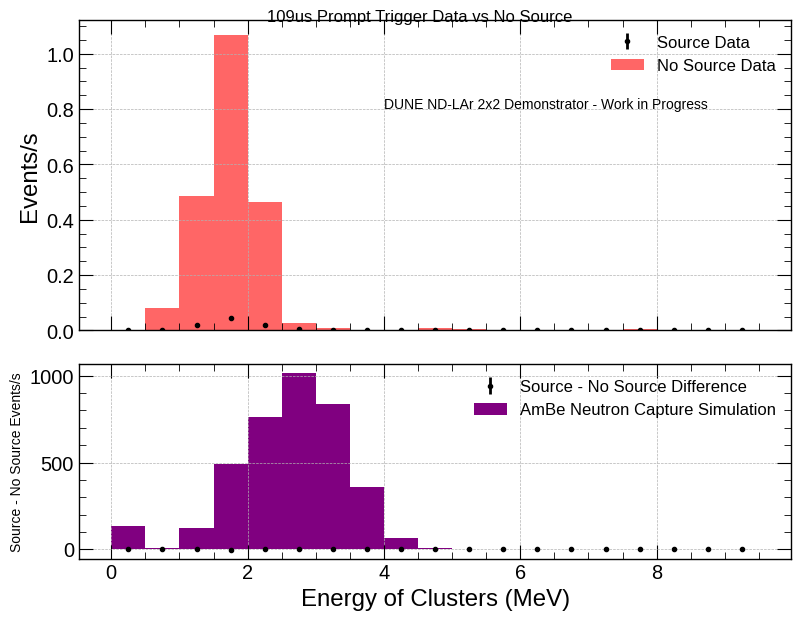

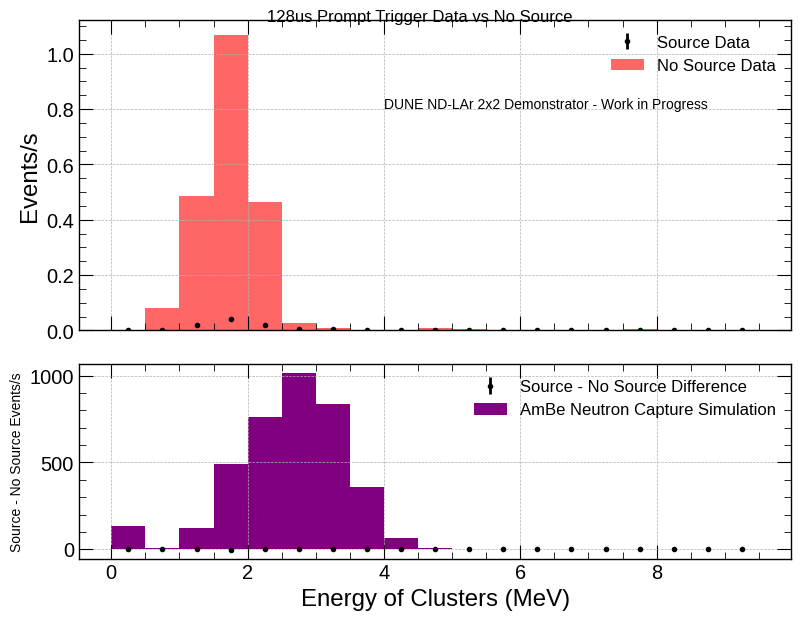

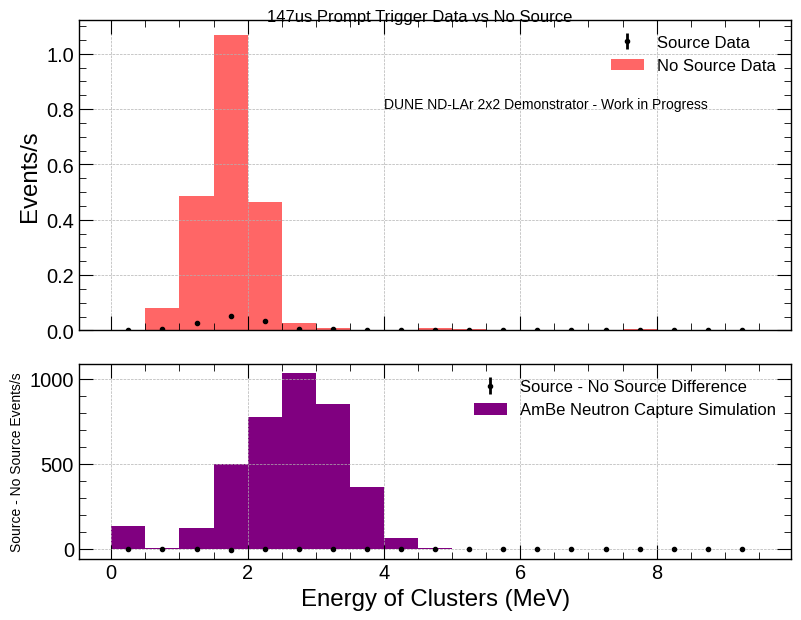

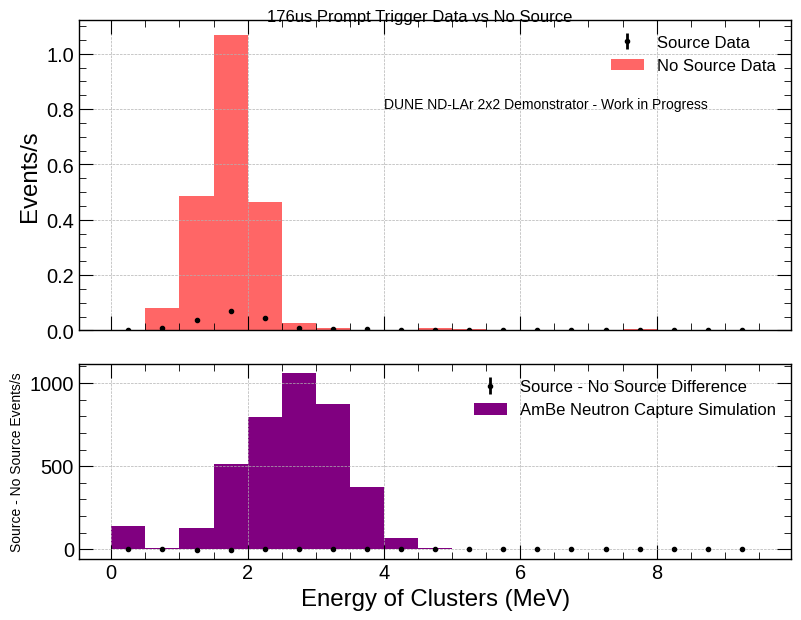

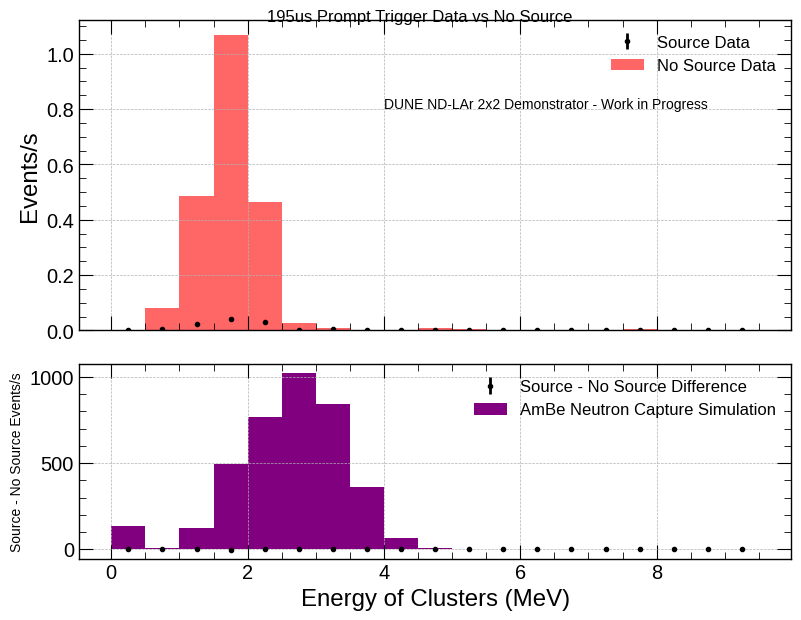

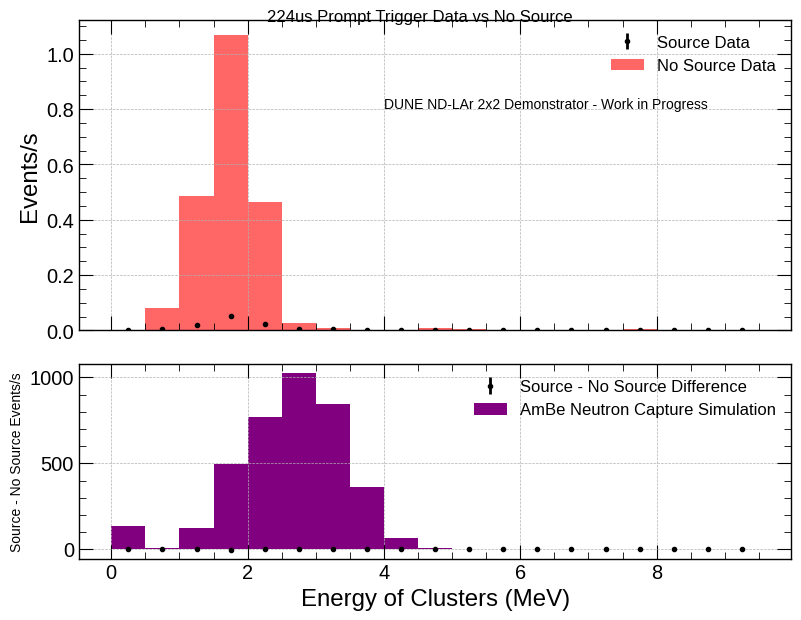

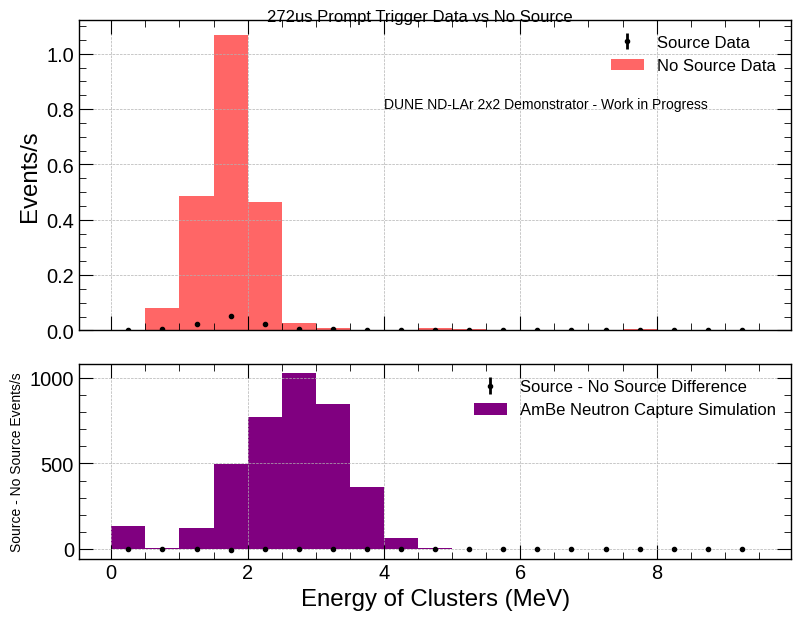

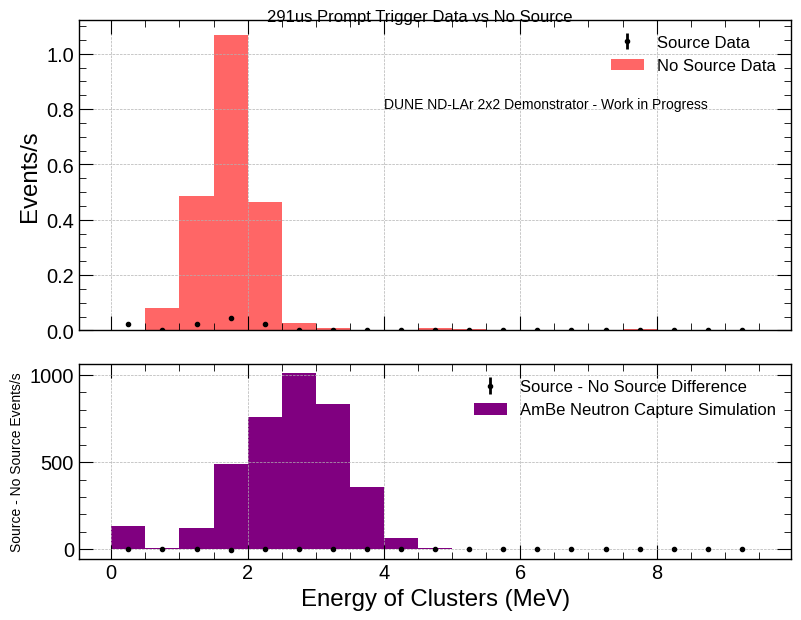

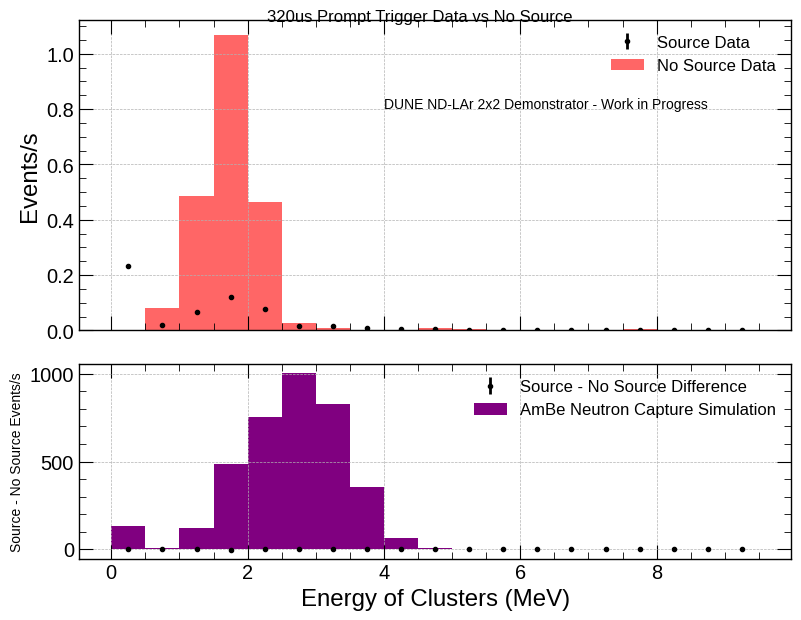

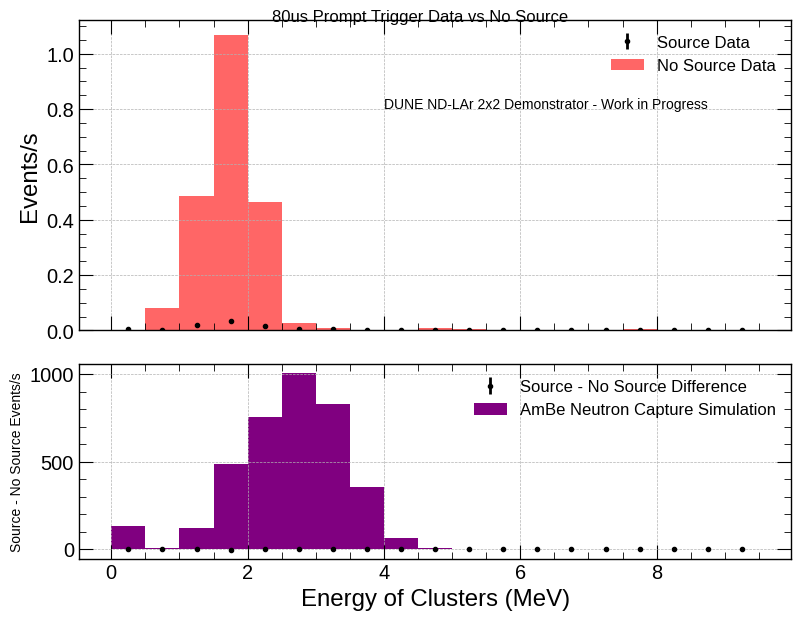

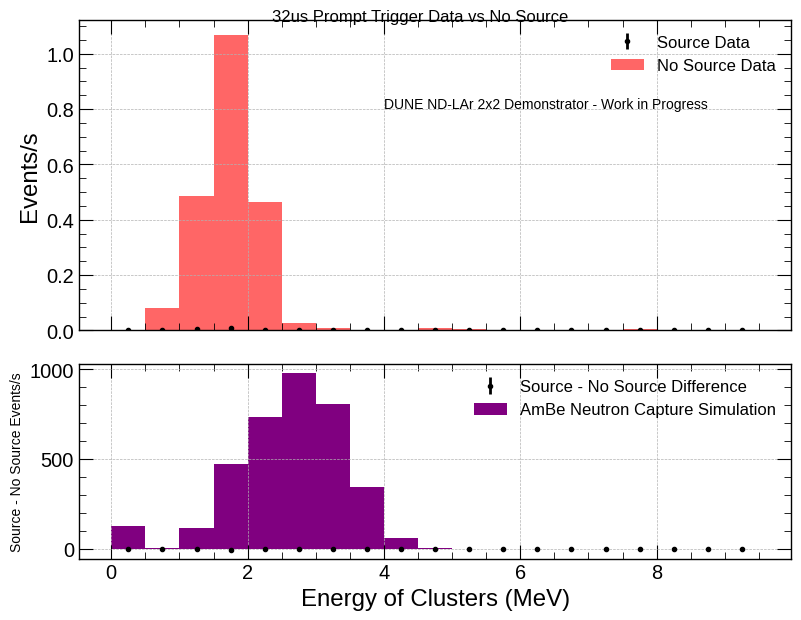

In [ ]:
all_prompt_data_clustE_li = []
all_prompt_data_exposure = 0

for index,source_df in enumerate(df_source_li):
    # cluster energies & exposure time
    clust_E = get_clust_E(source_df, min_clust_size=4)
    #clust_exposure = get_exposure_prompt(source_df)
    clust_exposure = exposure_times[index]
    source_clust_E_hist, _ = np.histogram(clust_E, bins=bins_range)
    source_clust_E_hist = source_clust_E_hist/clust_exposure
    #source_clust_E_hist = source_clust_E_hist
    source_clust_E_hist_err = np.sqrt(source_clust_E_hist*clust_exposure)/clust_exposure
    #source_clust_E_hist_err = np.sqrt(source_clust_E_hist)

    # Calculate difference between source distribution and MC
    source_nosource_diff = source_clust_E_hist-nosource_clust_E_hist
    source_nosource_diff_err = np.sqrt(np.abs(source_nosource_diff))

    # Normalize the MC by the integral of the source no source difference
    MC_clust_E_hist_norm = MC_clust_E_hist/sum(abs(source_nosource_diff))

    # Export cluster E
    all_prompt_data_clustE_li.append(clust_E)
    all_prompt_data_exposure += clust_exposure

    # Comparison plots
    f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

    f.tight_layout()

    a0.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_clust_E_hist, yerr=source_clust_E_hist_err, linestyle='none', color='black',  marker='.', label='Source Data')
    a0.bar(bins_range[:-1], nosource_clust_E_hist, width=np.diff(bins_range), align='edge', label='No Source Data', color='red', alpha=0.6)

    a1.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_nosource_diff, yerr=np.sqrt(np.abs(source_nosource_diff)), linestyle='none', color='black', marker='.', label='Source - No Source Difference')
    a1.bar(bins_range[:-1], MC_clust_E_hist_norm, color='purple', width=np.diff(bins_range), align='edge', label='AmBe Neutron Capture Simulation')

    a1.set_xlabel('Energy of Clusters (MeV)')
    a1.set_ylabel('Source - No Source Events/s', fontsize=10)
    a0.set_ylabel('Events/s')
    a0.text(4.0, max([max(source_clust_E_hist), max(nosource_clust_E_hist)])*0.75, 'DUNE ND-LAr 2x2 Demonstrator - Work in Progress')
    a0.grid(True)
    a1.grid(True)
    #plt.yscale('log')
    #a0.set_ylim((0,550))
    a0.legend()
    a1.legend()
    plt.suptitle(f'{periods[index]}us Prompt Trigger Data vs No Source')
    plt.show()

In [ ]:
# Comparison plots for all available data
f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_clust_E_hist, yerr=source_clust_E_hist_err, linestyle='none', color='black',  marker='.', label='Source Data')
a0.bar(bins_range[:-1], nosource_clust_E_hist, width=np.diff(bins_range), align='edge', label='No Source Data', color='red', alpha=0.6)

a1.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_nosource_diff, yerr=np.sqrt(np.abs(source_nosource_diff)), linestyle='none', color='black', marker='.', label='Source - No Source Difference')
a1.hist(MC_clust_E_hist, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a1.set_ylabel('Source - No Source Events/s', fontsize=10)
a0.set_ylabel('Events/s')
a0.text(5.0, max([max(source_clust_E_hist), max(nosource_clust_E_hist)])*0.75, 'DUNE ND-LAr 2x2 Demonstrator - Work in Progress')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
#a0.set_ylim((0,550))
a0.legend()
a1.legend()
plt.suptitle(f'{periods[index]}us Prompt Trigger Data vs No Source')
plt.show()

In [ ]:
# Three tasks: 
# Generate cluster energy spectrum comparison plot
# Generate charge-light matched comparison plot
# Finish writing